In [116]:
from scipy.ndimage import label
import numpy as np
import matplotlib.pyplot as plt

Generated 100x100 Blob Array:
[[2 2 2 ... 1 2 2]
 [2 2 2 ... 1 2 2]
 [2 2 2 ... 1 1 1]
 ...
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]]

Array shape: (100, 100)
Unique values: [0 1 2]

Distribution of values: {np.int64(0): np.int64(3334), np.int64(1): np.int64(3333), np.int64(2): np.int64(3333)}
(Note: The counts should now be much more balanced)


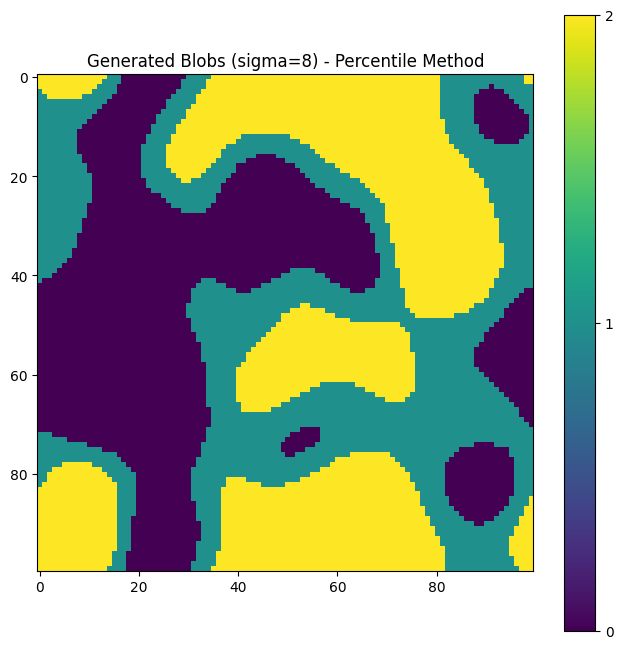

In [123]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def generate_blob_array(size=(100, 100), num_values=3, sigma=5):
    """
    Generates a NumPy array with random blobs of constant integer values.

    This version uses percentile-based quantization to ensure a balanced
    distribution of the final integer values, preventing the middle value
    from dominating.

    Args:
        size (tuple): The (height, width) of the output array.
        num_values (int): The number of distinct integer values (e.g., 3 for 0, 1, 2).
        sigma (float): The standard deviation for the Gaussian kernel.
                       Larger values create larger, smoother blobs.

    Returns:
        np.ndarray: A 2D NumPy array of integers with the specified blob structure.
    """
    # 1. Create an initial array of random integers.
    # The values will be in the range [0, num_values - 1].
    initial_array = np.random.randint(0, num_values, size=size)

    # 2. Apply a Gaussian filter to the random array.
    # This smooths the array, turning the random points into blobs.
    # The output will be an array of floating-point numbers.
    # 'wrap' mode ensures the blobs seamlessly connect at the edges.
    smoothed_array = gaussian_filter(initial_array.astype(float), sigma=sigma, mode='wrap')

    # 3. Quantize using percentiles to ensure a balanced distribution.
    # This avoids the issue where the middle value (e.g., 1) dominates.
    
    # Create an empty array to store the final integer values.
    blob_array = np.zeros_like(smoothed_array, dtype=int)
    
    # Calculate the percentile values that will serve as our thresholds.
    # For num_values=3, we need 2 thresholds (at 33.3% and 66.7%).
    # The result is an array of percentile points, e.g., [33.33, 66.66].
    percentile_points = np.linspace(0, 100, num_values + 1)[1:-1]
    
    # Find the actual values in the smoothed array that correspond to these percentiles.
    thresholds = np.percentile(smoothed_array, percentile_points)

    # Assign integer values based on which threshold bin each pixel falls into.
    # Values below the first threshold will remain 0.
    for i in range(len(thresholds)):
        # For each threshold, find all pixels with a value greater than it
        # and assign them the next integer value.
        blob_array[smoothed_array > thresholds[i]] = i + 1

    return blob_array

# --- Main execution ---
if __name__ == '__main__':
    # Generation parameters
    ARRAY_SIZE = (100, 100)
    BLOB_SMOOTHNESS = 8  # Try changing this value (e.g., 3, 5, 10)

    # Generate the blob array
    blobs = generate_blob_array(size=ARRAY_SIZE, sigma=BLOB_SMOOTHNESS)

    # Print the resulting array (optional)
    print("Generated 100x100 Blob Array:")
    print(blobs)
    print(f"\nArray shape: {blobs.shape}")
    print(f"Unique values: {np.unique(blobs)}")

    # --- Verification of distribution ---
    # Count the occurrences of each unique value
    unique, counts = np.unique(blobs, return_counts=True)
    distribution = dict(zip(unique, counts))
    print(f"\nDistribution of values: {distribution}")
    print("(Note: The counts should now be much more balanced)")

    # --- Visualization (requires matplotlib) ---
    try:
        plt.figure(figsize=(8, 8))
        # We use 'viridis' colormap and set vmin/vmax to ensure consistent colors
        # for the three distinct values (0, 1, 2).
        plt.imshow(blobs, cmap='viridis', interpolation='nearest', vmin=0, vmax=2)
        plt.title(f'Generated Blobs (sigma={BLOB_SMOOTHNESS}) - Percentile Method')
        plt.colorbar(ticks=[0, 1, 2])
        plt.show()
    except ImportError:
        print("\nMatplotlib not found. Skipping visualization.")
        print("To install: pip install matplotlib")


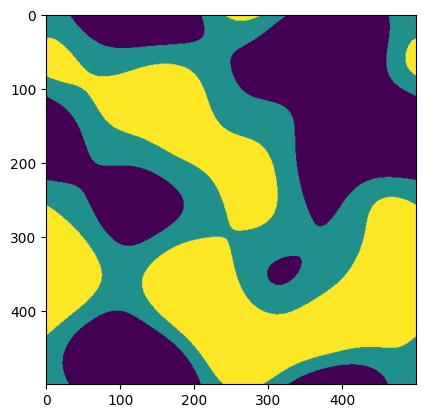

In [141]:
data = generate_blob_array(size=(500,500), sigma=50)
plt.imshow(data)

6

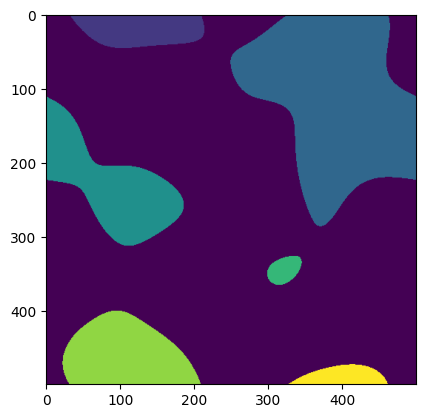

In [161]:
labeled = label(data==0)
plt.imshow(labeled[0])
labeled[1]

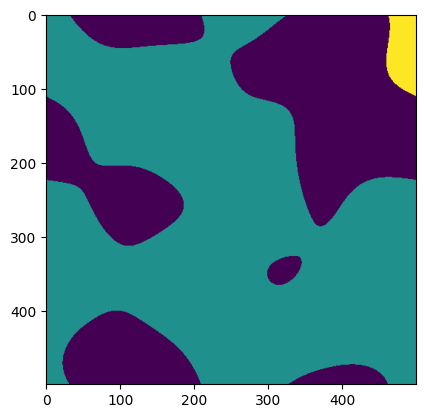

In [93]:
labeled[0]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(100, 100), dtype=int32)